In [30]:
from gam_rs_utils.utils import *
from src.rset_opt import RSetOPT
from src.run_app import get_models_from_rset
from method_scripts.results import Results
import random

In [31]:
dn = 'compas'
data = pd.read_csv(f'datasets/{dn}.csv')
l0 = 0.001
l2 = 0.001
m = 1.01

fastsparse_data = Results.create_fastsparse_dataset(dn, l0, l2)
cum_X = fastsparse_data['cum_X']
cum_header = fastsparse_data['cum_header']
bin_X = fastsparse_data['bin_X']
bin_header = fastsparse_data['bin_header']
y = fastsparse_data['y']
w = fastsparse_data['w']

print("data shape", data.shape)
print("cum_X shape", cum_X.shape)
print("w", len(w), "y", len(y), "header", len(cum_header), cum_header[:10])

loading dataset from results/compas/l0_0.001_l2_0.001.pkl
Loading cached fastsparse dataset for compas with l0=0.001 and l2=0.001
data shape (6907, 8)
cum_X shape (6907, 142)
w 142 y 6907 header 142 Index(['intercept', 'sex=female<=0', 'sex=female<=1', 'age<=18', 'age<=19',
       'age<=20', 'age<=21', 'age<=22', 'age<=23', 'age<=24'],
      dtype='object')


In [32]:
import numpy as np

# ---------- 0. prepare data ----------

# cum_X: (n_samples, n_features) binary matrix
# y: (n_samples,) vector of 0/1 labels
# cum_header: list of feature names (len = n_features)

X = cum_X.values if hasattr(cum_X, "values") else cum_X
y_arr = y.values.astype(float) if hasattr(y, "values") else y.astype(float)

n, K = X.shape

# optional: always keep intercept (assume column 0)
INTERCEPT_IDX = 0

# ---------- 1. MAP logistic regression + Laplace score ---------- 
from sklearn.linear_model import LogisticRegression
import numpy as np

def map_logistic_theta(X_S, y, sigma2, max_iter=1000):
    # C is inverse of reg strength; C ≈ sigma2 is a rough mapping
    clf = LogisticRegression(
        penalty="l2",
        C=sigma2,
        fit_intercept=False,
        solver="lbfgs",
        max_iter=max_iter,
    )
    clf.fit(X_S, y)
    theta_hat = clf.coef_.ravel()
    proba = clf.predict_proba(X_S)[:, 1]
    return theta_hat, proba

def hessian_and_logdet(X_S, proba, sigma2, jitter=1e-6):
    # proba = π_i = P(y_i=1)
    p = np.clip(proba, 1e-8, 1.0 - 1e-8)
    W = p * (1.0 - p)          # (n,)
    XTW = X_S.T * W            # each row scaled by W
    A = XTW @ X_S + (1.0 / sigma2) * np.eye(X_S.shape[1])

    # add a tiny jitter on top of the prior to ensure positive definiteness
    A += jitter * np.eye(A.shape[0])

    # compute log det via Cholesky if possible
    try:
        L = np.linalg.cholesky(A)      # A = L L^T
        logdet = 2.0 * np.sum(np.log(np.diag(L)))
    except np.linalg.LinAlgError:
        print("np.linalg.LinAlgError")
        # fallback to slogdet
        sign, logdet = np.linalg.slogdet(A)
        if sign <= 0:
            # last resort: just make it something finite
            logdet = np.log(np.abs(np.linalg.det(A)) + 1e-12)

    return A, logdet

def evaluate_score_laplace(S, X, y, sigma2, p_feat, K, max_iter=1000):
    """
    J(S) ≈ log P(S) + log P(D | S, θ̂_S) + log P(θ̂_S) - 0.5 log det(A_S)
    """

    idx = np.array(sorted(list(S)), dtype=int)
    X_S = X[:, idx]
    n, d = X_S.shape

    # 1. MAP θ and probabilities
    theta_hat, proba = map_logistic_theta(X_S, y, sigma2=sigma2, max_iter=max_iter)

    # 2. log-likelihood at θ̂
    eps = 1e-12
    log_likelihood = np.sum(
        y * np.log(proba + eps) + (1.0 - y) * np.log(1.0 - proba + eps)
    )

    # 3. log prior on θ (Gaussian N(0, σ² I), constants dropped)
    log_prior_theta = -0.5 * np.dot(theta_hat, theta_hat) / sigma2

    # 4. Hessian and logdet for Laplace Occam factor
    _, logdet = hessian_and_logdet(X_S, proba, sigma2=sigma2)

    # 5. Laplace log-marginal (ignoring constants that cancel in MH)
    #    L(S) ≈ log_likelihood + log_prior_theta - 0.5 * logdet
    L_S = log_likelihood + log_prior_theta - 0.5 * logdet

    # 6. sparsity prior on S: Bernoulli(p_feat) per feature
    #    log P(S) = |S| log p_feat + (K - |S|) log(1 - p_feat)
    k = len(S)
    log_prior_S = k * np.log(p_feat) + (K - k) * np.log(1.0 - p_feat)

    # 7. total score
    J_S = L_S + log_prior_S

    return J_S, (log_likelihood, log_prior_theta, 0.5 * logdet, log_prior_S)

# ---------- 2. Proposal ---------- 
def propose_swap(S, K, intercept_idx=0):
    """
    one-step proposal that preserves support size:
      - choose one non-intercept feature in S to remove
      - choose one feature outside S to add

    S            : current support (set of indices)
    K            : total number of features (0..K-1)
    intercept_idx: index of intercept column (kept fixed)
    """

    current = set(S)

    # all non-intercept indices
    all_features = set(range(K))
    all_features.discard(intercept_idx)

    in_set  = [j for j in current if j != intercept_idx]
    out_set = list(all_features - current)

    if len(in_set) == 0 or len(out_set) == 0:
        # degenerate: nothing to swap, return same support
        return current

    # pick one to drop, one to add
    f_remove = random.choice(in_set)
    f_add    = random.choice(out_set)

    S_prop = set(current)
    S_prop.remove(f_remove)
    S_prop.add(f_add)

    return S_prop

# ---------- 3. Metropolis-Hastings ---------- 
def mh_sample_supports(X, y, sigma2=10.0, n_steps=2000, p_feat=0.01, beta=0.025, burn_in=500, init_support=None, intercept_idx=0):
    """
    Metropolis–Hastings sampler over supports of fixed size 'target_size_total'.

    X, y              : data
    sigma2            : prior variance on weights (L2 strength)
    target_size_total : total number of features in support (incl. intercept)
    n_steps           : total MH steps
    p_feat            : expected sparsity
    beta              : MH acceptance ratio parameter
    burn_in           : steps to discard
    init_support      : optional initial support (list/iterable of indices)
    intercept_idx     : index of intercept column
    """

    n, K = X.shape

    # ---------- 1. initialize support ----------

    if init_support is not None:
        S_current = set(init_support)
        S_current.add(intercept_idx)
    else:
        S_current = {intercept_idx}

    # initial score
    J_current_raw, terms = evaluate_score_laplace(S_current, X, y, sigma2=sigma2, p_feat=p_feat, K=K)

    samples = []
    scores = []

    accepts = 0

    # ---------- 2. MCMC loop ----------
    for t in range(n_steps):
        # propose a swap that keeps |S| fixed
        S_prop = propose_swap(S_current, K, intercept_idx=intercept_idx)

        # evaluate proposed support
        J_prop_raw, terms = evaluate_score_laplace(S_prop, X, y, sigma2=sigma2, p_feat=p_feat, K=K)

        # MH acceptance ratio (log scale); proposal symmetric so no q terms
        log_alpha = beta * (J_prop_raw - J_current_raw)

        u = np.random.rand()
        if np.log(u) < min(0.0, log_alpha):
            accepts += 1
            S_current = S_prop
            J_current_raw = J_prop_raw

        # store after burn-in
        if t >= burn_in:
            samples.append(set(S_current))
            scores.append(J_current_raw)

        if (t + 1) % 100 == 0:
            acc_rate = accepts / (t+1)
            print(f"step {t+1}, |S|={len(S_current)}, J={J_current_raw:.2f} ({terms[0]:.2f}, {terms[1]:.2f}, {terms[2]:.2f}, {terms[3]:.2f}), accept_rate={acc_rate:.3f}")

    return samples, scores


In [33]:
def random_sample_supports(X, y, support_size, n_samples, sigma2=10.0, p_feat=0.01, intercept_idx=0):
    n, K = X.shape
    samples = []
    scores = []
    for t in range(n_samples):
        S_current = set(random.sample(range(K), support_size - 1))
        S_current.add(intercept_idx)
        J_current_raw, terms = evaluate_score_laplace(S_current, X, y, sigma2=sigma2, p_feat=p_feat, K=K)
        print(f"step {t+1}, |S|={len(S_current)}, J={J_current_raw:.2f} ({terms[0]:.2f}, {terms[1]:.2f}, {terms[2]:.2f}, {terms[3]:.2f})")
        samples.append(S_current)
        scores.append(J_current_raw)
    return samples, scores

In [34]:
samples, scores = mh_sample_supports(
    X=X,
    y=y_arr,
    sigma2=5.0,            # tune this if needed
    p_feat=0.01,
    beta=0.025,
    n_steps=2000,
    burn_in=500,
    init_support=w.nonzero()[0].tolist(),
    intercept_idx=INTERCEPT_IDX,
)

print("num samples:", len(samples))

random_samples, random_scores = random_sample_supports(
    X=X,
    y=y_arr,
    support_size=len(w.nonzero()[0].tolist()),
    n_samples=30,
    sigma2=5.0,
)
print("num random samples:", len(random_samples))

step 100, |S|=11, J=-2547.36 (-2569.56, -0.98, 18.12, -51.97), accept_rate=0.460
step 200, |S|=11, J=-2497.64 (-2671.01, -0.78, 19.06, -51.97), accept_rate=0.430
step 300, |S|=11, J=-2377.50 (-2514.42, -0.68, 22.65, -51.97), accept_rate=0.477
step 400, |S|=11, J=-2417.59 (-2341.09, -0.31, 24.21, -51.97), accept_rate=0.475
step 500, |S|=11, J=-2567.77 (-2611.88, -1.15, 23.23, -51.97), accept_rate=0.476
step 600, |S|=11, J=-2504.94 (-2429.80, -0.75, 22.42, -51.97), accept_rate=0.485
step 700, |S|=11, J=-2525.57 (-2450.65, -0.94, 22.01, -51.97), accept_rate=0.494
step 800, |S|=11, J=-2577.41 (-2506.11, -0.82, 18.50, -51.97), accept_rate=0.504
step 900, |S|=11, J=-2451.06 (-2766.19, -0.39, 23.59, -51.97), accept_rate=0.508
step 1000, |S|=11, J=-2499.95 (-2893.02, -0.86, 19.23, -51.97), accept_rate=0.511
step 1100, |S|=11, J=-2462.69 (-2454.40, -0.92, 19.68, -51.97), accept_rate=0.513
step 1200, |S|=11, J=-2587.35 (-2511.36, -0.79, 23.22, -51.97), accept_rate=0.510
step 1300, |S|=11, J=-245

In [ ]:
samples = samples[::50]
scores = scores[::50]
for sample in samples:
    print(sample)

{0, 2626, 484, 1445, 2698, 42, 2574, 2447, 2352, 2771, 3414, 2489, 3134}
{0, 2784, 1760, 3684, 2698, 2574, 2447, 3196, 3414, 2489, 3228, 2557, 735}
{0, 3561, 2698, 2444, 2574, 2447, 2896, 977, 2232, 2489, 3196, 2557, 3519}
{0, 2884, 2698, 2444, 1228, 2574, 2447, 2129, 2581, 3030, 2489, 3196, 2557}
{0, 1191, 2698, 267, 2444, 2235, 2574, 2447, 2935, 2296, 2489, 2555, 3196}
{0, 1926, 2698, 2603, 2444, 2188, 2574, 2447, 2514, 3191, 2935, 2489, 2555}
{0, 1926, 2698, 2603, 2444, 2489, 2574, 2447, 2935, 3191, 825, 2138, 2555}
{0, 2048, 2562, 1496, 2698, 441, 2444, 2447, 2933, 3191, 472, 2489, 924}
{0, 2562, 2371, 1443, 3144, 2698, 2444, 2733, 2447, 2933, 3414, 2489, 2079}
{0, 3072, 2562, 3491, 513, 2698, 2444, 2447, 3414, 793, 2489, 124, 285}
{0, 3072, 2562, 2726, 2698, 2444, 2508, 2447, 2129, 3442, 3414, 2489, 1085}
{0, 3072, 2562, 98, 2698, 3672, 2444, 2285, 2447, 3442, 3410, 920, 2489}
{0, 2562, 2949, 2698, 3179, 2444, 588, 2447, 1392, 3410, 915, 2489, 2366}
{0, 2562, 3170, 2698, 3083, 244

In [7]:
# sample = samples[0]
# sample = sorted(list(sample))
# w = np.zeros(K)
# w[sample] = 1
# sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)
# sparse_gam_file = prepare_sparse_gam(dn, l0, l2, m, sparse_X, y, cum_header, sparse_header)

# model = RSetOPT(sparse_gam_file)
# model.finetune_ellipsoid()
# H_opt = model.get_normalized_H()
# model.update_file(H_opt, model.w_orig)

# with open(sparse_gam_file, 'rb') as f:
#     sparse_gam_data = pickle.load(f)

In [17]:
all_w_samples = []
for sample_set in [samples, random_samples]:
    w_samples = []
    for sample in sample_set:
        sample = sorted(list(sample))
        print(sample)
        w = np.zeros(K)
        w[sample] = 1
        sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)
        sparse_gam_file = prepare_sparse_gam(dn, l0, l2, m, sparse_X, y, cum_header, sparse_header)

        model = RSetOPT(sparse_gam_file)
        model.finetune_ellipsoid()
        H_opt = model.get_normalized_H()
        model.update_file(H_opt, model.w_orig)

        with open(sparse_gam_file, 'rb') as f:
            sparse_gam_data = pickle.load(f)

        w_samples.append(sparse_gam_data['w_orig'])
    all_w_samples.append(w_samples)

[0, 42, 484, 1445, 2352, 2447, 2489, 2574, 2626, 2698, 2771, 3134, 3414]
objective: 0.2601070299015881 objective in LR 0.2601070299015881
m:1.01, log objective:0.2601070299015881, eps:0.26270810020060403
----------- before optimization -----------
volume proportional to  tensor(9.3229e+21, dtype=torch.float64, grad_fn=<MulBackward0>)
----------- after optimization -----------
volume proportional to  tensor(2.6442e+21, dtype=torch.float64, grad_fn=<MulBackward0>)
[0, 735, 1760, 2447, 2489, 2557, 2574, 2698, 2784, 3196, 3228, 3414, 3684]
objective: 0.26475153565534004 objective in LR 0.26475153565534004
m:1.01, log objective:0.26475153565534004, eps:0.26739905101189343
----------- before optimization -----------
volume proportional to  tensor(5.9183e+21, dtype=torch.float64, grad_fn=<MulBackward0>)
----------- after optimization -----------
volume proportional to  tensor(1.2276e+21, dtype=torch.float64, grad_fn=<MulBackward0>)
[0, 977, 2232, 2444, 2447, 2489, 2557, 2574, 2698, 2896, 3196

In [18]:
print(all_w_samples[0][0])

[-0.43286146 -0.46163899  0.56279577 -0.60722173 -0.44083633 -0.11971724
 -1.28339792 -0.11466611 -1.20119267 -0.48178235  1.19375811 -2.93896429
 -1.04126121 -0.73876826  0.34658121  1.00521465  2.70020123 -0.57068727
  0.21606839]


In [ ]:
def get_binned_w_samples(samples, w_samples):
    binned_w_samples = []
    losses = []
    for sample, theta in zip(samples, w_samples):
        sample = sorted(list(sample))
        w = np.zeros(K)
        w[sample] = 1
        sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)

        header_object = ModelUtils.get_header_object(cum_header)
        sparse_header_object = ModelUtils.get_header_object(sparse_header)
        expanded_theta = ModelUtils.expand_w(theta, sparse_header_object, header_object)

        loss_a = ModelUtils.get_loss_one_model(
            sparse_X, y, 
            theta, 
            sample_p = Results.get_sample_proportion(sparse_X),
            loss_type='logistic', l2=0.001, 
        )
        # print(loss_a)

        loss_b = ModelUtils.get_loss_one_model(
            bin_X, y,
            expanded_theta, 
            sample_p = Results.get_sample_proportion(bin_X),
            loss_type='logistic', l2=0.001, 
        )
        # print(loss_b)
        
        # print(np.allclose(loss_a, loss_b))
        binned_w_samples.append(expanded_theta)
        losses.append(loss_a)

    binned_w_samples = np.vstack(binned_w_samples)
    return binned_w_samples, losses

binned_mcmc_w_samples, mcmc_losses = get_binned_w_samples(samples, all_w_samples[0])
binned_random_w_samples, random_losses = get_binned_w_samples(random_samples, all_w_samples[1])

In [21]:
binned_mcmc_w_samples.shape

(30, 3719)

In [22]:
len(bin_header)

3719

In [23]:
binned_mcmc_w_samples[:,1:].shape, np.array(bin_header[1:]).shape

((30, 3718), (3718,))

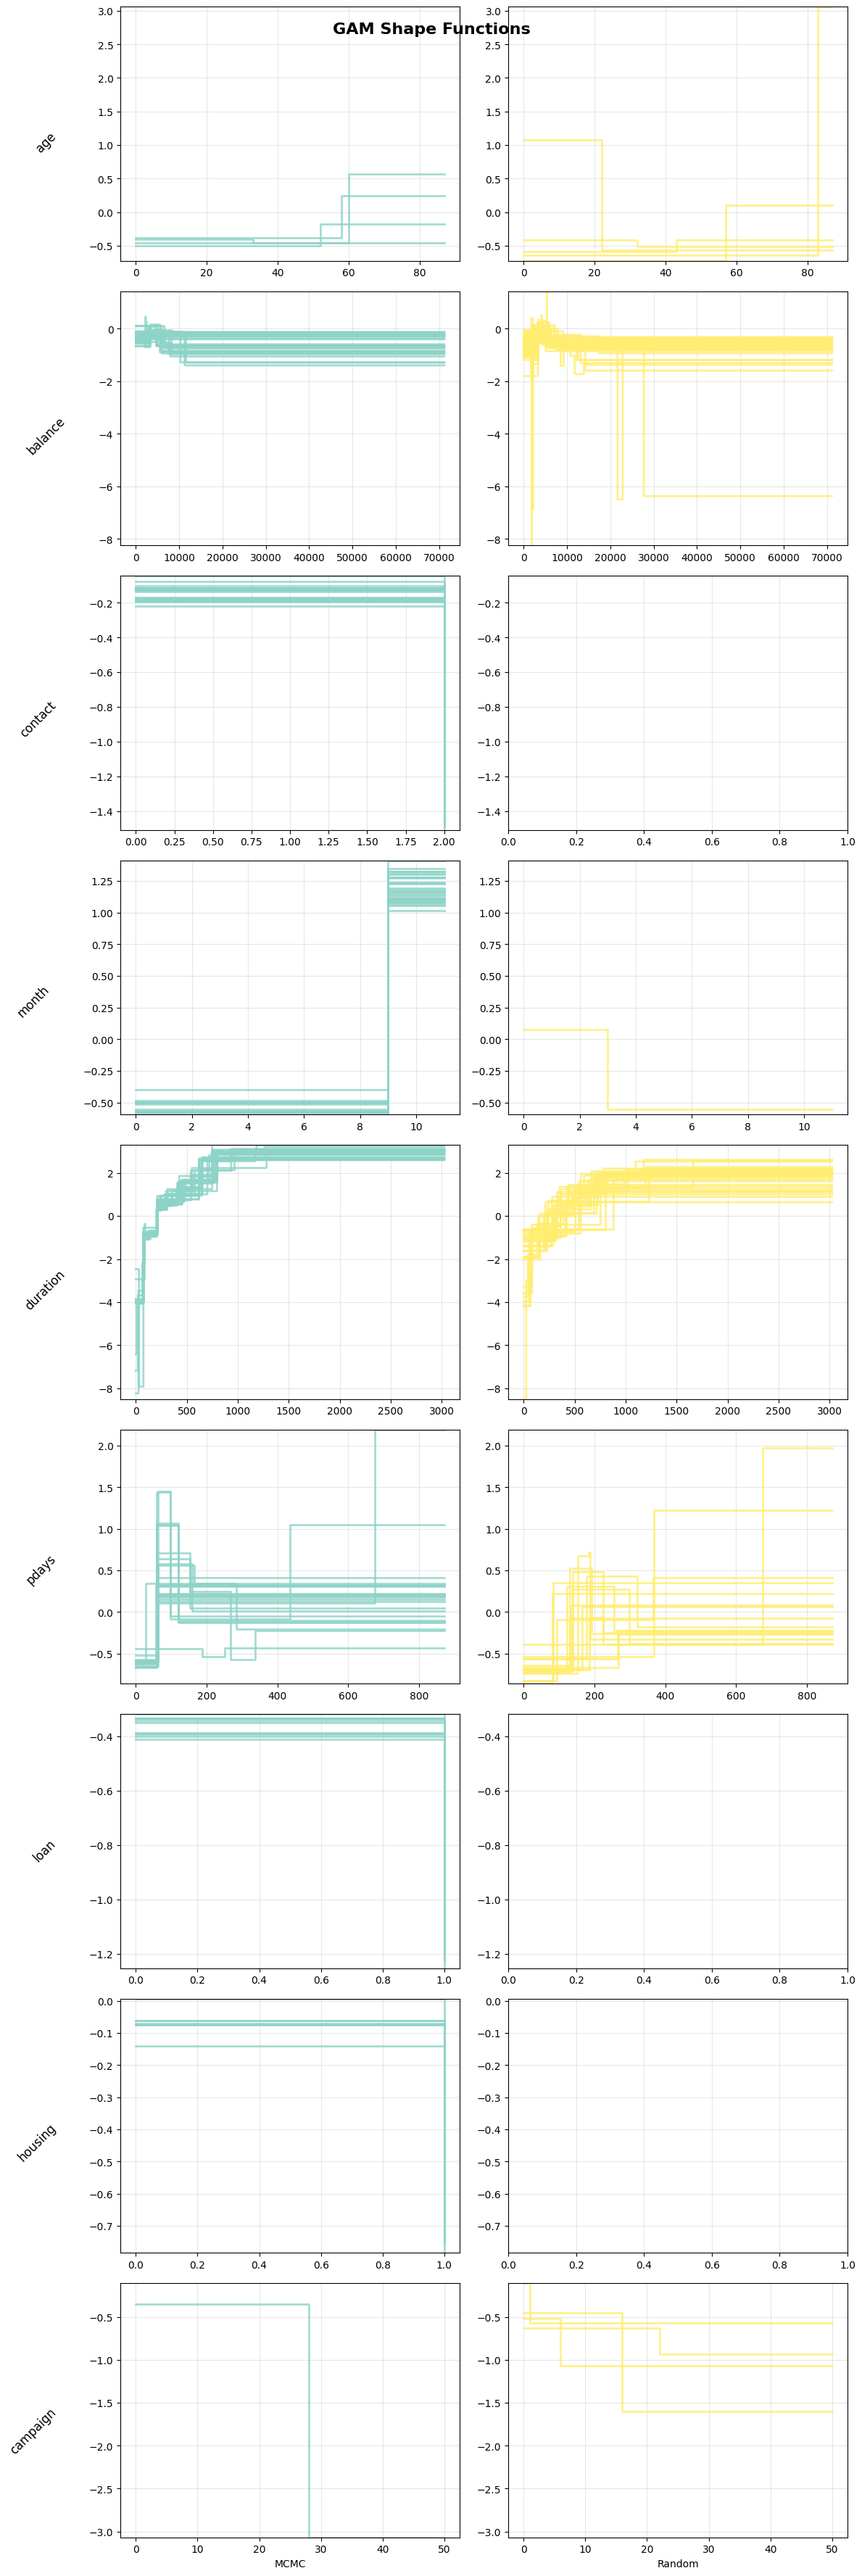

In [24]:
plotter = MultiPlotter(title=f"GAM Shape Functions")
plotter.add_shape_function(np.array(bin_header[1:]), binned_mcmc_w_samples[:,1:], 'MCMC')
plotter.add_shape_function(np.array(bin_header[1:]), binned_random_w_samples[:,1:], 'Random')
fig = plotter.plot_shape_functions()

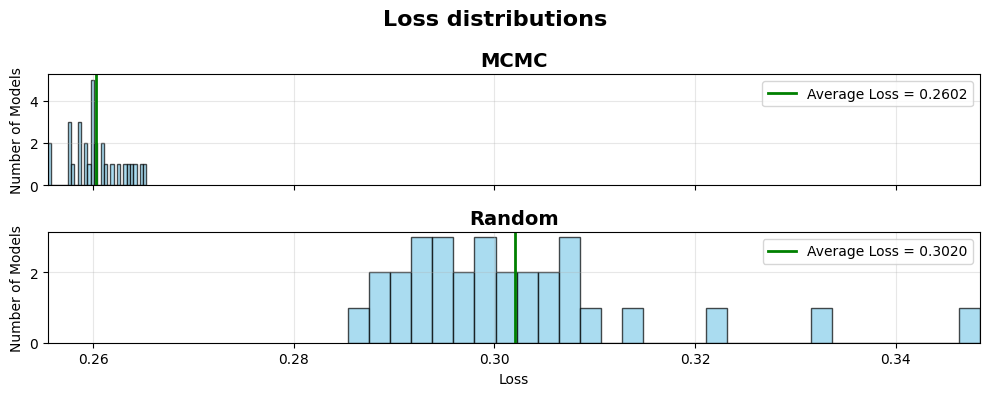

In [25]:
plotter = MultiPlotter(title=f"Loss distributions")
plotter.add_distribution(mcmc_losses, 'MCMC')
plotter.add_distribution(random_losses, 'Random')
fig = plotter.plot_distributions()